# Лабораторная работа по физике "Кольца Ньютона"

In [42]:
# --------------------------- Подключение библиотек -------------------------- #
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["text.usetex"] = False

In [43]:
# --------------------------------- Константы -------------------------------- #
# Угол преломления и погрешность (получен по измерениям транспортира) (Градус)
beta = 22
delta_beta = 0.5

# Показатель преломления среды
n = 1

# Длина волны света
lambda_light = 0.547 * 1e-3

# Абсолютная погрешность диаметра колец Ньютона
delta_d = 0.01

In [44]:
# --------------------------- Результаты измерений --------------------------- #
tests = [
    [
        31.31,
        31.43,
        31.55,
        31.72,
        31.89,
        32.03,
        32.22,
        32.46,
        32.74,
        33.06,
        34.56,
        35.00,
        35.31,
        35.53,
        35.71,
        35.88,
        36.05,
        36.20,
        36.36,
        36.48
    ],
    [
        31.2,
        31.43,
        31.59,
        31.71,
        31.86,
        32.02,
        32.22,
        32.45,
        32.73,
        33.09,
        34.62,
        34.99,
        35.26,
        35.5,
        35.69,
        35.87,
        36.03,
        36.18,
        36.34,
        36.48,
    ],
    [
        31.2,
        31.43,
        31.57,
        31.72,
        31.9,
        32.04,
        32.26,
        32.47,
        32.74,
        33.08,
        34.63,
        35.02,
        35.29,
        35.56,
        35.75,
        35.91,
        36.06,
        36.19,
        36.36,
        36.49,
    ],
    [
        31.28,
        31.43,
        31.58,
        31.71,
        31.89,
        32.02,
        32.21,
        32.47,
        32.77,
        33.07,
        34.61,
        35.02,
        35.27,
        35.5,
        35.69,
        35.89,
        36.04,
        36.17,
        36.33,
        36.49,
    ],
]

In [45]:
def diameter_ring(l1: float, l2: float) -> float:
    """Нахождение диаметра кольца Ньютона по показаниям микрометра"""
    diameter = abs(l1 - l2)
    return diameter


def error_diameter_ring(diameter: float, delta_diameter: float) -> float:
    """Нахождение абсолютной погрешности диаметра кольца Ньютона по показаниям микрометра"""
    error_diameter = 2 * diameter * delta_diameter
    return error_diameter

## Диаметр колец Ньютона

In [46]:
diameters_rings = []
for test in tests:
    diameters_rings.append(
        [diameter_ring(test[k], test[-k - 1]) for k in range(len(test) // 2)]
    )

diameters_rings

[[5.169999999999998,
  4.93,
  4.650000000000002,
  4.329999999999998,
  3.990000000000002,
  3.6799999999999997,
  3.3100000000000023,
  2.8500000000000014,
  2.259999999999998,
  1.5],
 [5.279999999999998,
  4.910000000000004,
  4.59,
  4.32,
  4.009999999999998,
  3.6699999999999946,
  3.280000000000001,
  2.809999999999995,
  2.260000000000005,
  1.529999999999994],
 [5.290000000000003,
  4.93,
  4.619999999999997,
  4.340000000000003,
  4.009999999999998,
  3.710000000000001,
  3.3000000000000043,
  2.8200000000000003,
  2.280000000000001,
  1.5500000000000043],
 [5.210000000000001,
  4.899999999999999,
  4.590000000000003,
  4.329999999999998,
  4.0,
  3.6699999999999946,
  3.289999999999999,
  2.8000000000000043,
  2.25,
  1.5399999999999991]]

In [47]:
Deltas_d = []

diameters_rings_av = []

for i in range(len(diameters_rings[0])):
    print(f'{10 - i} & ', end='')
    d_av = 0
    for j in range(len(diameters_rings)):
        print(f'{round(diameters_rings[j][i], 2)} & ', end='')
        d_av += diameters_rings[j][i]
    d_av /= 4
    
    diameters_rings_av.append(d_av)

    print(f'{round(d_av, 2)} & ', end='')
    delta_av = 0
    for j in range(len(diameters_rings)):
        print(f'{abs(round(diameters_rings[j][i] - d_av, 2))} & ', end='')
        delta_av += abs(round(diameters_rings[j][i] - d_av, 2))
    delta_av /= 4

    print(f'{round(delta_av, 2)} &', end='')
    Delta_d = 0.01
    Delta_d_av = np.sqrt(Delta_d**2 + delta_av**2)
    Deltas_d.append(Delta_d_av)
    print(f' {round(Delta_d_av, 2)} \\\\')
Deltas_d

10 & 5.17 & 5.28 & 5.29 & 5.21 & 5.24 & 0.07 & 0.04 & 0.05 & 0.03 & 0.05 & 0.05 \\
9 & 4.93 & 4.91 & 4.93 & 4.9 & 4.92 & 0.01 & 0.01 & 0.01 & 0.02 & 0.01 & 0.02 \\
8 & 4.65 & 4.59 & 4.62 & 4.59 & 4.61 & 0.04 & 0.02 & 0.01 & 0.02 & 0.02 & 0.02 \\
7 & 4.33 & 4.32 & 4.34 & 4.33 & 4.33 & 0.0 & 0.01 & 0.01 & 0.0 & 0.01 & 0.01 \\
6 & 3.99 & 4.01 & 4.01 & 4.0 & 4.0 & 0.01 & 0.01 & 0.01 & 0.0 & 0.01 & 0.01 \\
5 & 3.68 & 3.67 & 3.71 & 3.67 & 3.68 & 0.0 & 0.01 & 0.03 & 0.01 & 0.01 & 0.02 \\
4 & 3.31 & 3.28 & 3.3 & 3.29 & 3.3 & 0.02 & 0.02 & 0.01 & 0.01 & 0.02 & 0.02 \\
3 & 2.85 & 2.81 & 2.82 & 2.8 & 2.82 & 0.03 & 0.01 & 0.0 & 0.02 & 0.01 & 0.02 \\
2 & 2.26 & 2.26 & 2.28 & 2.25 & 2.26 & 0.0 & 0.0 & 0.02 & 0.01 & 0.01 & 0.01 \\
1 & 1.5 & 1.53 & 1.55 & 1.54 & 1.53 & 0.03 & 0.0 & 0.02 & 0.01 & 0.02 & 0.02 \\


[np.float64(0.048541219597369005),
 np.float64(0.016007810593582122),
 np.float64(0.02462214450449026),
 np.float64(0.011180339887498949),
 np.float64(0.0125),
 np.float64(0.016007810593582122),
 np.float64(0.01802775637731995),
 np.float64(0.018027756377319945),
 np.float64(0.0125),
 np.float64(0.01802775637731995)]

In [48]:
str = "1 & 5.17 & 5.28 & 5.29 & 5.21 & 5.24 & 0.07 & 0.04 & 0.05 & 0.03 & 0.05 & 0.05 \\\\ \n \
2 & 4.93 & 4.91 & 4.93 & 4.9 & 4.92 & 0.01 & 0.01 & 0.01 & 0.02 & 0.01 & 0.02 \\\\ \n \
3 & 4.65 & 4.59 & 4.62 & 4.59 & 4.61 & 0.04 & 0.02 & 0.01 & 0.02 & 0.02 & 0.02 \\\\ \n \
4 & 4.33 & 4.32 & 4.34 & 4.33 & 4.33 & 0.0 & 0.01 & 0.01 & 0.0 & 0.01 & 0.01 \\\\ \n \
5 & 3.99 & 4.01 & 4.01 & 4.0 & 4.0 & 0.01 & 0.01 & 0.01 & 0.0 & 0.01 & 0.01 \\\\ \n \
6 & 3.68 & 3.67 & 3.71 & 3.67 & 3.68 & 0.0 & 0.01 & 0.03 & 0.01 & 0.01 & 0.02 \\\\ \n \
7 & 3.31 & 3.28 & 3.3 & 3.29 & 3.3 & 0.02 & 0.02 & 0.01 & 0.01 & 0.02 & 0.02 \\\\ \n \
8 & 2.85 & 2.81 & 2.82 & 2.8 & 2.82 & 0.03 & 0.01 & 0.0 & 0.02 & 0.01 & 0.02 \\\\ \n \
9 & 2.26 & 2.26 & 2.28 & 2.25 & 2.26 & 0.0 & 0.0 & 0.02 & 0.01 & 0.01 & 0.01 \\\\ \n \
10 & 1.5 & 1.53 & 1.55 & 1.54 & 1.53 & 0.03 & 0.0 & 0.02 & 0.01 & 0.02 & 0.02 \\\\"
str = str.replace(".", ",", -1)
print(str)

1 & 5,17 & 5,28 & 5,29 & 5,21 & 5,24 & 0,07 & 0,04 & 0,05 & 0,03 & 0,05 & 0,05 \\ 
 2 & 4,93 & 4,91 & 4,93 & 4,9 & 4,92 & 0,01 & 0,01 & 0,01 & 0,02 & 0,01 & 0,02 \\ 
 3 & 4,65 & 4,59 & 4,62 & 4,59 & 4,61 & 0,04 & 0,02 & 0,01 & 0,02 & 0,02 & 0,02 \\ 
 4 & 4,33 & 4,32 & 4,34 & 4,33 & 4,33 & 0,0 & 0,01 & 0,01 & 0,0 & 0,01 & 0,01 \\ 
 5 & 3,99 & 4,01 & 4,01 & 4,0 & 4,0 & 0,01 & 0,01 & 0,01 & 0,0 & 0,01 & 0,01 \\ 
 6 & 3,68 & 3,67 & 3,71 & 3,67 & 3,68 & 0,0 & 0,01 & 0,03 & 0,01 & 0,01 & 0,02 \\ 
 7 & 3,31 & 3,28 & 3,3 & 3,29 & 3,3 & 0,02 & 0,02 & 0,01 & 0,01 & 0,02 & 0,02 \\ 
 8 & 2,85 & 2,81 & 2,82 & 2,8 & 2,82 & 0,03 & 0,01 & 0,0 & 0,02 & 0,01 & 0,02 \\ 
 9 & 2,26 & 2,26 & 2,28 & 2,25 & 2,26 & 0,0 & 0,0 & 0,02 & 0,01 & 0,01 & 0,01 \\ 
 10 & 1,5 & 1,53 & 1,55 & 1,54 & 1,53 & 0,03 & 0,0 & 0,02 & 0,01 & 0,02 & 0,02 \\


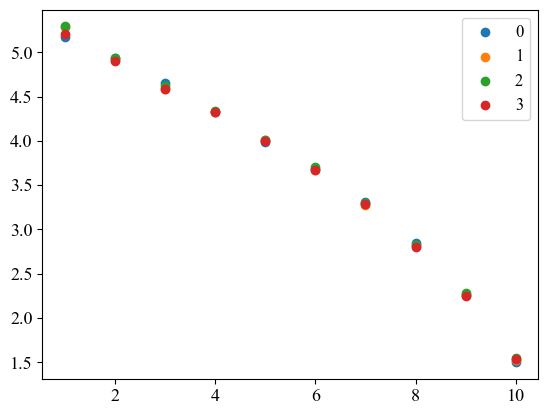

In [49]:
pupu = [i+1 for i in range(10)]

plt.scatter(pupu, diameters_rings[0])
plt.scatter(pupu, diameters_rings[1])
plt.scatter(pupu, diameters_rings[2])
plt.scatter(pupu, diameters_rings[3])

plt.legend(['0', '1', '2', '3'])

## Квадрат диметра колец Ньютона

In [50]:
square_diameters_rings = []

for diameters in diameters_rings:
    square_diameters_rings.append([diameter**2 for diameter in diameters])

for row in square_diameters_rings:
    print(*[round(i, 2) for i in row], sep='\t')

26.73	24.3	21.62	18.75	15.92	13.54	10.96	8.12	5.11	2.25
27.88	24.11	21.07	18.66	16.08	13.47	10.76	7.9	5.11	2.34
27.98	24.3	21.34	18.84	16.08	13.76	10.89	7.95	5.2	2.4
27.14	24.01	21.07	18.75	16.0	13.47	10.82	7.84	5.06	2.37


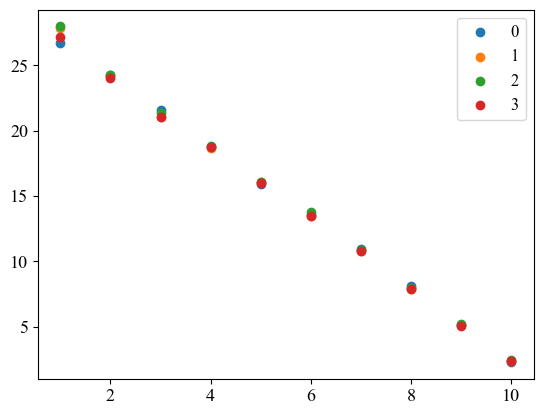

In [51]:
pupu = [i+1 for i in range(10)]

plt.scatter(pupu, square_diameters_rings[0])
plt.scatter(pupu, square_diameters_rings[1])
plt.scatter(pupu, square_diameters_rings[2])
plt.scatter(pupu, square_diameters_rings[3])

plt.legend(['0', '1', '2', '3'])

In [52]:
error_diameters_rings = []

for i in range(len(square_diameters_rings[0])):
    print(f'{10 - i} & ', end='')
    d_av = 0
    for j in range(len(square_diameters_rings)):
        print(f'{round(square_diameters_rings[j][i], 2)} & ', end='')
        d_av += square_diameters_rings[j][i]
    d_av /= 4

    print(f'{round(d_av, 2)} & ', end='')
    
    Delta_d = 0.01
    Delta_d_av = 2 * diameters_rings[j][i] * Deltas_d[i]
    error_diameters_rings.append(Delta_d_av)

    print(f' {round(Delta_d_av, 2)} \\\\')

10 & 26.73 & 27.88 & 27.98 & 27.14 & 27.43 &  0.51 \\
9 & 24.3 & 24.11 & 24.3 & 24.01 & 24.18 &  0.16 \\
8 & 21.62 & 21.07 & 21.34 & 21.07 & 21.28 &  0.23 \\
7 & 18.75 & 18.66 & 18.84 & 18.75 & 18.75 &  0.1 \\
6 & 15.92 & 16.08 & 16.08 & 16.0 & 16.02 &  0.1 \\
5 & 13.54 & 13.47 & 13.76 & 13.47 & 13.56 &  0.12 \\
4 & 10.96 & 10.76 & 10.89 & 10.82 & 10.86 &  0.12 \\
3 & 8.12 & 7.9 & 7.95 & 7.84 & 7.95 &  0.1 \\
2 & 5.11 & 5.11 & 5.2 & 5.06 & 5.12 &  0.06 \\
1 & 2.25 & 2.34 & 2.4 & 2.37 & 2.34 &  0.06 \\


## Погрешность квадрата диаметра колец Ньютона

In [53]:
errors_square_diameters_rings = []

for diameters in diameters_rings:
    errors_square_diameters_rings.append(
        [
            error_diameter_ring(diameter=diameter, delta_diameter=delta_d)
            for diameter in diameters
        ]
    )

for row in errors_square_diameters_rings:
    print(*[round(i*100000, 3) for i in row], sep='\t')

10340.0	9860.0	9300.0	8660.0	7980.0	7360.0	6620.0	5700.0	4520.0	3000.0
10560.0	9820.0	9180.0	8640.0	8020.0	7340.0	6560.0	5620.0	4520.0	3060.0
10580.0	9860.0	9240.0	8680.0	8020.0	7420.0	6600.0	5640.0	4560.0	3100.0
10420.0	9800.0	9180.0	8660.0	8000.0	7340.0	6580.0	5600.0	4500.0	3080.0


In [54]:
def radius_lens(
    diameter: float, k: int, lam: float = lambda_light, beta: float = beta, n: float = n
) -> float:
    """Вычисление радиуса линзы"""
    radius = (n * math.cos(math.radians(beta))) / (4 * lam) * (diameter**2) / k
    return radius


def error_radius_lens(
    diameter: float,
    k: int,
    lam: float = lambda_light,
    beta: float = beta,
    n: float = n,
    delta_beta: float = delta_beta,
    delta_diameter: float = delta_d,
) -> float:
    """Вычисление погрешности радиуса линзы"""
    first = 1 / (4 * lam * k)
    second = 2 * diameter * delta_diameter * math.cos(math.radians(beta))
    three = diameter**2 * math.radians(delta_beta) * math.sin(math.radians(beta))
    error_radius = first * (second + three)
    return round(error_radius, 2) 

## Радиус линзы

In [55]:
Deltas_d, diameters_rings_av

([np.float64(0.048541219597369005),
  np.float64(0.016007810593582122),
  np.float64(0.02462214450449026),
  np.float64(0.011180339887498949),
  np.float64(0.0125),
  np.float64(0.016007810593582122),
  np.float64(0.01802775637731995),
  np.float64(0.018027756377319945),
  np.float64(0.0125),
  np.float64(0.01802775637731995)],
 [5.2375,
  4.9175,
  4.612500000000001,
  4.33,
  4.0024999999999995,
  3.6824999999999974,
  3.2950000000000017,
  2.8200000000000003,
  2.262500000000001,
  1.5299999999999994])

In [56]:
radius_lenses = []
k = 10
for diameters in diameters_rings_av:
    radius_lenses.append(
            radius_lens(diameters, k)
    )
    k -= 1

ind = 10
for var in radius_lenses:
    print(f'{ind} & {(round(var, 2))} & {round(error_radius_lens(diameters_rings_av[10 - ind], ind, delta_diameter=Deltas_d[10 - ind]), 2)}  \\\\')
    ind -= 1

Deltas_d[0], diameters_rings_av[0]

10 & 1162.43 & 25.65  \\
9 & 1138.58 & 11.43  \\
8 & 1126.94 & 16.0  \\
7 & 1135.0 & 9.86  \\
6 & 1131.44 & 11.06  \\
5 & 1149.3 & 14.04  \\
4 & 1150.19 & 16.64  \\
3 & 1123.3 & 18.32  \\
2 & 1084.59 & 15.81  \\
1 & 991.98 & 26.87  \\


(np.float64(0.048541219597369005), 5.2375)

np.float64(1119.374849234667)

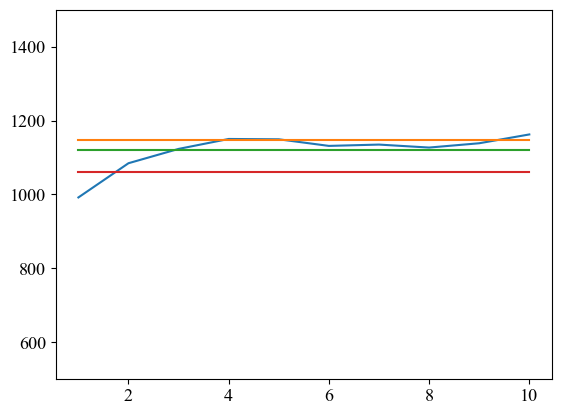

In [57]:
plt.plot(pupu, np.flip(radius_lenses))
plt.plot([1, 10], [1147.3908395346439, 1147.3908395346439])

av = np.average(radius_lenses)
plt.plot([1, 10], [av, av])
plt.plot([1, 10], [1060, 1060])
plt.ylim(500, 1500)

av

## Погрешность радиуса линзы

## Аппроксимация квадрата диаметра

In [58]:
def approx_line_y_kx_b(x_data: float, y_data: float) -> tuple[float, float]:
    """Аппроксимирование данных методом наименьших квадратов для линейной функции"""
    l = len(x_data)
    s_x = sum(x_data)
    s_y = sum(y_data)
    s_xx = sum([i**2 for i in x_data])
    s_xy = sum([i * j for i, j in zip(x_data, y_data)])
    
    k = (l * s_xy - s_x * s_y) / (l * s_xx - s_x**2)
    b = (s_xx * s_y - s_x * s_xy) / (l * s_xx - s_x**2)
    
    return k, b

def approx_line_y_kx(x_data: float, y_data: float) -> float:
    """Аппроксимирование данных методом наименьших квадратов для линейной функции"""
    l = len(x_data)
    s_xx = sum([i**2 for i in x_data])
    s_xy = sum([i * j for i, j in zip(x_data, y_data)])
    
    k = s_xy / s_xx
    
    return k



## Среднее значение квадрата диаметра кольца

In [59]:
middle_square_diameters = []

count_row = len(square_diameters_rings[0])
count_col = len(square_diameters_rings)

for index in range(count_row):
    middle_square_diameters.append(sum([square_diameters_rings[i][index] for i in range(count_col)]) / count_col)

middle_square_diameters

[27.433874999999997,
 24.181975000000005,
 21.275775000000007,
 18.74895,
 16.020074999999995,
 13.561074999999981,
 10.857150000000011,
 7.952750000000002,
 5.119025000000004,
 2.341249999999998]

## Среднее значение погрешности квадрата диаметра кольца

$$
\frac1n \sqrt{\sum_{i=1}^n \Delta x_{i}^2}
$$

In [60]:
middle_error_square_diameters = []

count_row = len(errors_square_diameters_rings[0])
count_col = len(errors_square_diameters_rings)

for row in range(count_row):
    middle_error_square_diameters.append(1 / count_col * math.sqrt(sum([errors_square_diameters_rings[col][row]**2 for col in range(count_col)])))
    
for var in middle_error_square_diameters:
    print(round(var*100000, 2))


5237.74
4917.52
4612.57
4330.01
4002.51
3682.54
3295.02
2820.06
2262.53
1530.11


In [61]:
import numpy as np
from scipy.optimize import curve_fit

k = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
d_squared = np.array([2.34, 5.12, 7.95, 10.86, 13.56, 16.02, 18.75, 21.28, 24.18, 27.43])
errors_d_squared = np.array([0.51, 0.16, 0.23, 0.10, 0.10, 0.12, 0.12, 0.10, 0.06, 0.06])

# Модель d^2 = a * k
def model(x, a):
    return a * x

# Взвешенный МНК
popt_w, pcov_w = curve_fit(model, k, d_squared, sigma=errors_d_squared, absolute_sigma=True)
a_w = popt_w[0]
delta_a_w = np.sqrt(pcov_w[0, 0])

# Параметры установки
lambda_mm = 5.47e-4  # 0.547 мкм в мм
beta_deg = 22.0
beta_rad = np.radians(beta_deg)
delta_beta_rad = np.radians(0.5)

# Радиус кривизны
R = a_w * np.cos(beta_rad) / (4 * lambda_mm)

# Погрешность радиуса
dR_da = np.cos(beta_rad) / (4 * lambda_mm)
dR_dbeta = -a_w * np.sin(beta_rad) / (4 * lambda_mm)  # минус, т.к. R ~ cosβ
# Но если брать по модулю для сложения погрешностей:
delta_R = np.sqrt((dR_da * delta_a_w)**2 + (dR_dbeta * delta_beta_rad)**2)

print(f"a = {a_w:.4f} ± {delta_a_w:.4f} мм²")
print(f"R = {R/1000:.3f} ± {delta_R/1000:.3f} м")
print(f"Относительная погрешность R: {delta_R/R*100:.1f}%")

a = 2.7077 ± 0.0039 мм²
R = 1.147 ± 0.004 м
Относительная погрешность R: 0.4%


In [62]:

N = len(diameters_rings_av) 
delta_a = 0

sum_d_a_delta = 0
k_sum = 0
for k in range(len(diameters_rings_av)):
    sum_d_a_delta += (diameters_rings_av[k]**2 - a_w * (k+1))**2
    k_sum += (k+1)**2

# for var in error_radius_lenses:
#     print(round(var * 1e-3, 2))
# 
delta_a = np.sqrt(sum_d_a_delta / ((N - 1) * k_sum))

print(f'{a_w=}, {delta_a_w=}, {diameters_rings_av=}, {error_diameters_rings=}')

diameters_rings_av, error_diameters_rings


a_w=np.float64(2.707651933903433), delta_a_w=np.float64(0.003863026206632019), diameters_rings_av=[5.2375, 4.9175, 4.612500000000001, 4.33, 4.0024999999999995, 3.6824999999999974, 3.2950000000000017, 2.8200000000000003, 2.262500000000001, 1.5299999999999994], error_diameters_rings=[np.float64(0.5057995082045851), np.float64(0.15687654381710475), np.float64(0.22603128655122076), np.float64(0.09682174342574086), np.float64(0.1), np.float64(0.1174973297568926), np.float64(0.11862263696276523), np.float64(0.10095543571299184), np.float64(0.05625), np.float64(0.05552548964214541)]


([5.2375,
  4.9175,
  4.612500000000001,
  4.33,
  4.0024999999999995,
  3.6824999999999974,
  3.2950000000000017,
  2.8200000000000003,
  2.262500000000001,
  1.5299999999999994],
 [np.float64(0.5057995082045851),
  np.float64(0.15687654381710475),
  np.float64(0.22603128655122076),
  np.float64(0.09682174342574086),
  np.float64(0.1),
  np.float64(0.1174973297568926),
  np.float64(0.11862263696276523),
  np.float64(0.10095543571299184),
  np.float64(0.05625),
  np.float64(0.05552548964214541)])

In [63]:
beta_r = math.radians(beta)

first = np.cos(beta_r) / (4 * lambda_light) * delta_a_w
second = np.sin(beta_r) / (4 * lambda_light) * a_w* math.radians(delta_beta)

error_radius_lense = first + second
error_radius_lense

np.float64(5.682454327081797)

In [64]:
a_w * math.cos(math.radians(beta)) / 4 / lambda_light

np.float64(1147.3908395346439)

[0.85, 10.15]


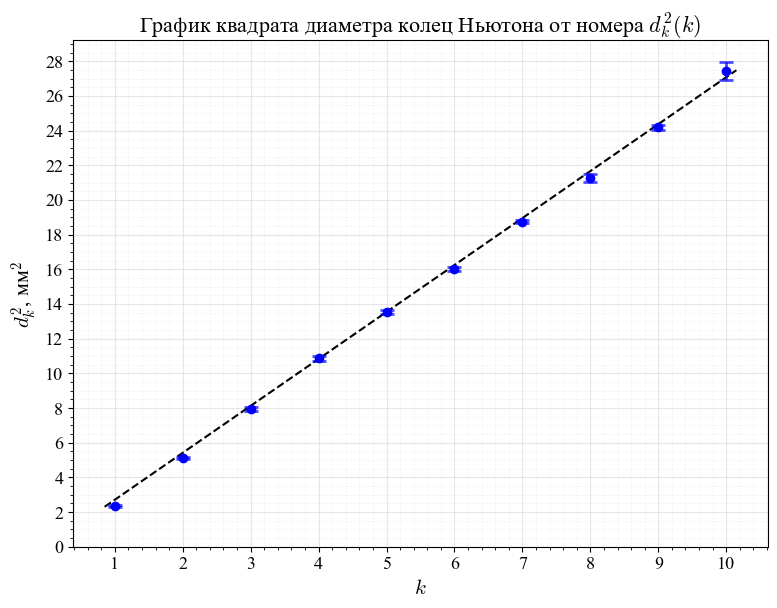

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))  # + явный размер

step = 0.15

colors = [
    "blue",
    "green",
    "red",
    "orange"
]
trend = lambda x: a_w * x

x_trend = [1-step, 10+step]
y_trend = [trend(i) for i in x_trend]

print(x_trend)
plt.plot(x_trend, y_trend, '--', color='black')

y_points = [i + 1 for i in range(10)][::-1]

length = len(square_diameters_rings)

# for index_test, (diameters, error_diameters, mid_diameters, mid_error_diameters) in enumerate(
#     zip(square_diameters_rings, errors_square_diameters_rings, middle_square_diameters, middle_error_square_diameters)
# ):
#     window_y = [y - step * (index_test - length // 2) for y in y_points]
#     ax.plot(window_y, diameters, "o", color=colors[index_test], alpha=0.05)
#     ax.errorbar(
#         window_y,
#         diameters,
#         yerr=error_diameters,
#         fmt="none",
#         capsize=5,
#         capthick=2,
#         elinewidth=2,
#         color=colors[index_test],
#         alpha=0.05,
#     )

plt.plot(y_points, middle_square_diameters, "o", color='blue')
ax.errorbar(
    y_points,
    middle_square_diameters,
    yerr=error_diameters_rings,
    fmt="none",
    capsize=5,
    capthick=2,
    elinewidth=2,
    color='blue',
    alpha=0.7,
)

plt.minorticks_on()

plt.xlabel("$k$")
plt.ylabel(r"$d_k^2$, $\text{мм}^2$")
plt.xticks(y_points)
plt.yticks(np.arange(0, 30, 2))
ax.grid(True, alpha=0.3)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.3)  
plt.tight_layout()
plt.title("График квадрата диаметра колец Ньютона от номера $d_k^2(k)$")
fig.savefig('graph_1.pdf', bbox_inches='tight')
plt.show()

In [66]:


middle_radius_lenses = np.average(radius_lenses)

In [67]:
middle_radius_lenses

np.float64(1119.374849234667)

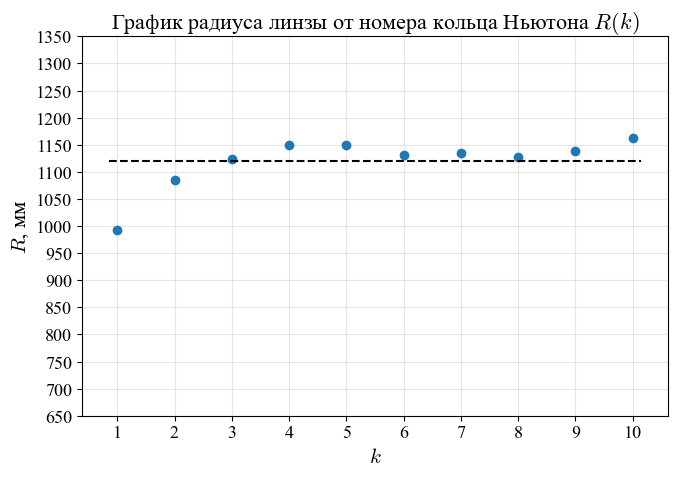

In [72]:
fig, ax = plt.subplots(figsize=(7, 5))

step = 0.15

y_points = [i for i in range(1, 11)]

colors = [
    'blue', 
    'green',
    'red', 
    'orange'
]

length = len(radius_lenses)
# for index, (r, de_r, col) in enumerate(zip(radius_lenses, error_radius_lenses, colors)):
#     window_y = [y - step * (index - length // 2) for y in y_points]
#     ax.plot(window_y, r, 'o', markersize=5, color=col, label=f"Измерение {index+1}")
#     ax.errorbar(window_y, r,
#                 yerr=de_r,
#                 fmt='none',
#                 capsize=5,
#                 capthick=2,
#                 elinewidth=2,
#                 ecolor=col,
#                 alpha=0.5)

plt.plot(y_points, np.flip(radius_lenses), 'o')
# ax.errorbar(y_points, tre,
#                 yerr=error_tre,
#                 fmt='none',
#                 capsize=5,
#                 capthick=2,
#                 elinewidth=2,
#                 ecolor='gray',
#                 alpha=0.5)
    
plt.plot([1-step, 10+step], [middle_radius_lenses] * 2, '--', color='black')
# plt.plot([1-step, 10+step], [1060.2288499068957] * 2, '--', color='blue')

plt.xlabel("$k$")
plt.ylabel("$R$, мм")
plt.xticks(y_points)
plt.yticks([i for i in range(650, 1400, 50)])
ax.grid(True, alpha=0.3)
plt.title("График радиуса линзы от номера кольца Ньютона $R(k)$")
plt.tight_layout()
fig.savefig('graph_2.pdf', bbox_inches='tight')
plt.show()

In [ ]:
radius_lenses

[[885.468451941966,
  1005.0263700308395,
  1065.5137038368332,
  1077.9201007023762,
  1065.8993745403448,
  1044.203429760097,
  1054.0672672136327,
  1063.6689778952878,
  1062.7764038323103,
  1051.8932313382934],
 [921.2413774004141,
  1005.0263700308457,
  1035.8144360561382,
  1058.4693103747172,
  1060.1143139876542,
  1054.6978706719997,
  1049.204218255349,
  1036.3965495754742,
  1054.1709622845503,
  1097.1308306941726],
 [945.4835359069267,
  1022.8931556833601,
  1043.199898847895,
  1071.4168268497815,
  1083.349006166615,
  1054.6978706719997,
  1058.9415602157537,
  1049.9884903127818,
  1062.7764038323103,
  1101.290564710631],
 [933.3231025002509,
  996.1520084347119,
  1028.4552093666719,
  1064.933230073892,
  1060.1143139876542,
  1049.444091190478,
  1054.0672672136327,
  1036.396549575476,
  1049.8813595618071,
  1068.2330758381302]]

In [ ]:
error_radius_lenses

[[11985.122264259986,
  9097.06717841348,
  7692.536889900579,
  6730.866385970228,
  6008.257034079235,
  5445.045190177562,
  5081.606390075889,
  4789.79541637198,
  4526.160910981063,
  4281.715689710657],
 [12228.473784807826,
  9097.067178413507,
  7581.592839245763,
  6667.905841137962,
  5991.346714620704,
  5473.4013071342615,
  5069.379946583373,
  4725.254798100806,
  4506.9317640927975,
  4377.43341550067],
 [12390.787632390222,
  9179.384810240274,
  7609.320901854438,
  6709.875562665292,
  6059.007072586895,
  5473.4013071342615,
  5093.83510501271,
  4757.5161634244705,
  4526.160910981063,
  4386.144567002178],
 [12309.622758543985,
  9055.920287582656,
  7553.870076673819,
  6688.88871438786,
  5991.346714620704,
  5459.221923646739,
  5081.606390075889,
  4725.25479810081,
  4497.319840667005,
  4316.499875298375]]

In [ ]:
(31.28 - 36.49), 31.31 - 36.48, 31.20 - 36.48

(-5.210000000000001, -5.169999999999998, -5.279999999999998)

In [ ]:
import random
from collections import Counter

# Создаём массив из 10000 случайных чисел от 0 до 10000
random_numbers = [random.randint(0, 10000) for _ in range(10000)]

# Подсчитываем количество повторений каждого числа
counter = Counter(random_numbers)

# Получаем 10 наиболее часто встречающихся чисел
most_common_ten = counter.most_common(10)

# Выводим результат
print("10 чисел с наибольшим количеством повторов:")
print("Число : Количество повторений")
for number, count in most_common_ten:
    print(f"{number:6} : {count}")

10 чисел с наибольшим количеством повторов:
Число : Количество повторений
  5412 : 7
  2521 : 6
  2242 : 6
  8016 : 6
  1377 : 6
  6253 : 6
  9984 : 6
  5299 : 5
  2895 : 5
  6651 : 5
